In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [5]:
df = pd.read_csv(r"Pakistan_2017_Census_Final (1).csv")

print(df.shape)
df.head()

(2073, 17)


,adm_lvl_1,adm_lvl_2,adm_lvl_3,adm_lvl_4,area_name,area_type,area_sq_km,total_pop,total_male,total_female,total_trans,sex_ratio,pop_density,pct_urban,avg_hh_size,total_pop_98,avg_annual_growth
0,BALOCHISTAN,NaN,NaN,NaN,BALOCHISTAN,TOTAL,347190.0,12335129.0,6483736.0,5850613.0,780.0,110.82,35.53,0.2762,6.87,6565885.0,0.0337
1,BALOCHISTAN,NaN,NaN,NaN,BALOCHISTAN,RURAL,NaN,8928428.0,4685756.0,4242183.0,489.0,110.46,NaN,NaN,6.80,4997105.0,0.0310
2,BALOCHISTAN,NaN,NaN,NaN,BALOCHISTAN,URBAN,NaN,3406701.0,1797980.0,1608430.0,291.0,111.78,NaN,NaN,7.06,1568780.0,0.0416
3,BALOCHISTAN,NaN,AWARAN,NaN,AWARAN DISTRICT,TOTAL,29510.0,121821.0,63063.0,58749.0,9.0,107.34,4.13,0.2810,6.61,118173.0,0.0016
4,BALOCHISTAN,NaN,AWARAN,NaN,AWARAN DISTRICT,RURAL,NaN,87584.0,45438.0,42138.0,8.0,107.83,NaN,NaN,6.25,118173.0,-0.0156


In [25]:
def clean_data(df):

    # Drop columns with 50% missing values
    missing_pct = df.isnull().mean() * 100
    cols_to_drop = missing_pct[missing_pct > 50].index
    df = df.drop(columns=cols_to_drop)

    # Numerical columns -> Median
    num_cols = df.select_dtypes(include=np.number).columns

    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    
    if "area_type" in df.columns:
        df["area_type"] = df["area_type"].fillna(
            df["area_type"].mode()[0]
        )

    # Remove duplicates
    df = df.drop_duplicates()

    # Derived Feature 1
    df["population_growth"] = (
        df["total_pop"] - df["total_pop_98"]
    )

    # Derived Feature 2
    df["male_female_ratio"] = (
        df["total_male"] / df["total_female"]
    )

    return df




### Why Median Instead of Mean?

Median was used to fill missing numerical values because census data may contain extreme values and outliers. The mean can be heavily influenced by unusually large or small observations, while the median provides a more robust estimate of the central tendency.

In [30]:
df = clean_data(df)

print(df.shape)
df.head()

(2073, 15)


,adm_lvl_1,adm_lvl_3,adm_lvl_4,area_name,area_type,total_pop,total_male,total_female,total_trans,sex_ratio,avg_hh_size,total_pop_98,avg_annual_growth,population_growth,male_female_ratio
0,BALOCHISTAN,KHUZDAR,NOWSHERA TEHSIL,BALOCHISTAN,TOTAL,12335129.0,6483736.0,5850613.0,780.0,110.82,6.87,6565885.0,0.0337,5769244.0,1.108215
1,BALOCHISTAN,KHUZDAR,NOWSHERA TEHSIL,BALOCHISTAN,RURAL,8928428.0,4685756.0,4242183.0,489.0,110.46,6.80,4997105.0,0.0310,3931323.0,1.104562
2,BALOCHISTAN,KHUZDAR,NOWSHERA TEHSIL,BALOCHISTAN,URBAN,3406701.0,1797980.0,1608430.0,291.0,111.78,7.06,1568780.0,0.0416,1837921.0,1.117848
3,BALOCHISTAN,AWARAN,NOWSHERA TEHSIL,AWARAN DISTRICT,TOTAL,121821.0,63063.0,58749.0,9.0,107.34,6.61,118173.0,0.0016,3648.0,1.073431
4,BALOCHISTAN,AWARAN,NOWSHERA TEHSIL,AWARAN DISTRICT,RURAL,87584.0,45438.0,42138.0,8.0,107.83,6.25,118173.0,-0.0156,-30589.0,1.078314


In [27]:
df_total = df[df["area_type"] == "TOTAL"]

print(df_total.shape)

(691, 15)


In [28]:
province = df_total.groupby("adm_lvl_1")[["total_pop_98","total_pop"]].sum()

print(province)

             total_pop_98    total_pop
adm_lvl_1                             
BALOCHISTAN    19697655.0   37005387.0
FATA            9528993.0   14979132.0
ISLAMABAD        805235.0    2003368.0
KP             70910137.0  122035680.0
PUNJAB        294485160.0  439958620.0
SINDH          91319679.0  143563530.0


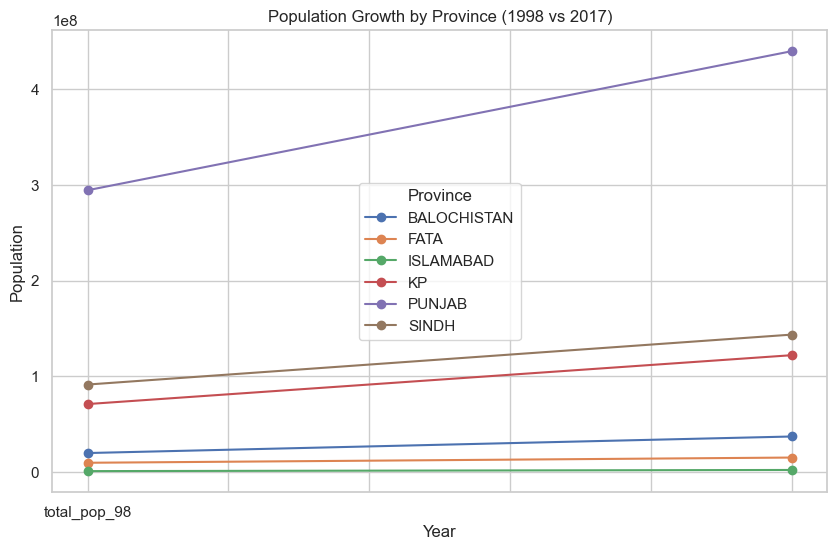

In [31]:
province.T.plot(marker="o")

plt.title("Population Growth by Province (1998 vs 2017)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend(title="Province")
plt.show()

In [32]:
province_gender = df_total.groupby("adm_lvl_1")[["total_male","total_female"]].sum()

print(province_gender)

              total_male  total_female
adm_lvl_1                             
BALOCHISTAN   19451208.0    17551839.0
FATA           7655145.0     7323009.0
ISLAMABAD      1052328.0      950760.0
KP            61777924.0    60249760.0
PUNJAB       223639096.0   216269784.0
SINDH         74628558.0    68917110.0


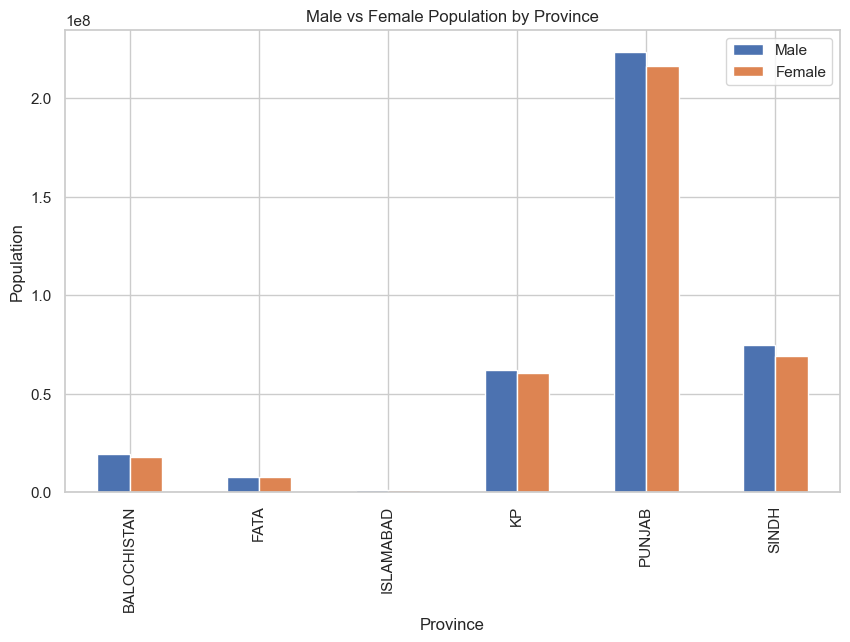

In [33]:
province_gender.plot(kind="bar")

plt.title("Male vs Female Population by Province")
plt.xlabel("Province")
plt.ylabel("Population")
plt.legend(["Male","Female"])

plt.show()

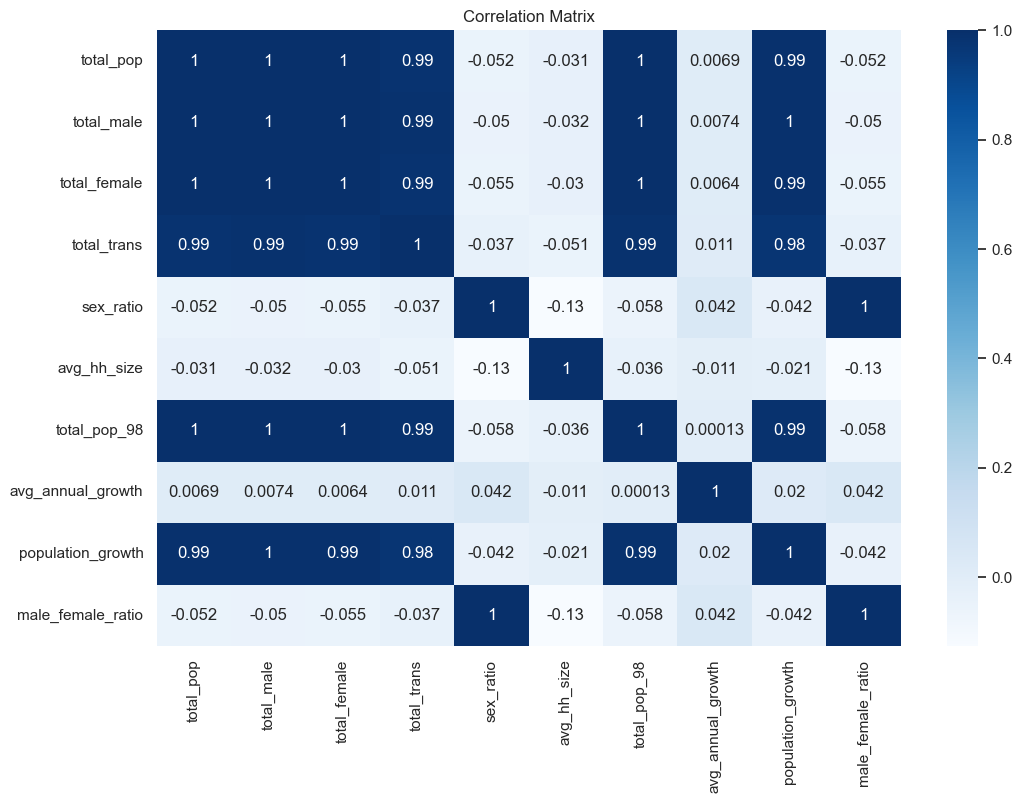

In [34]:
corr = df_total.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")
plt.show()

In [35]:
province_pop = (
    df_total.groupby("adm_lvl_1")["total_pop"]
    .sum()
    .sort_values()
)

print(province_pop)

adm_lvl_1
ISLAMABAD        2003368.0
FATA            14979132.0
BALOCHISTAN     37005387.0
KP             122035680.0
SINDH          143563530.0
PUNJAB         439958620.0
Name: total_pop, dtype: float64


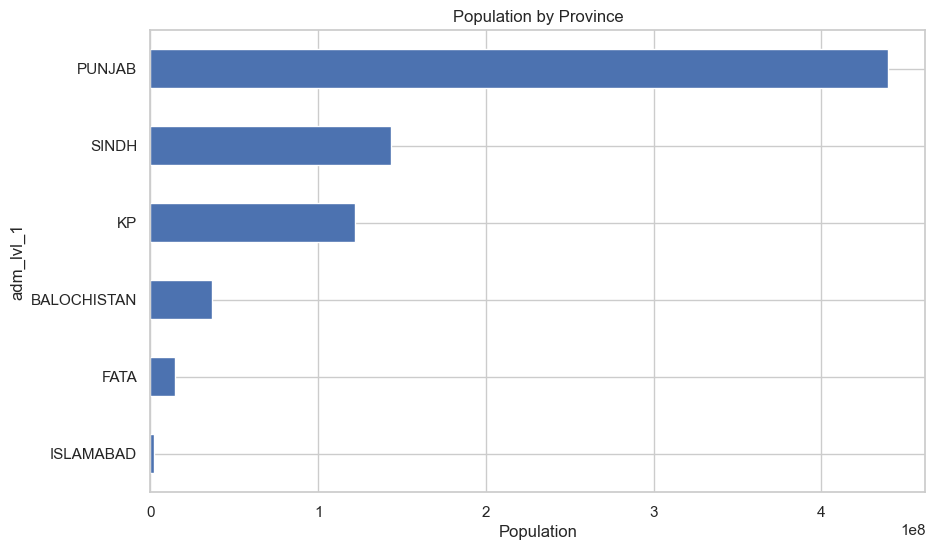

In [36]:
province_pop.plot(kind="barh")

plt.title("Population by Province")
plt.xlabel("Population")

plt.show()

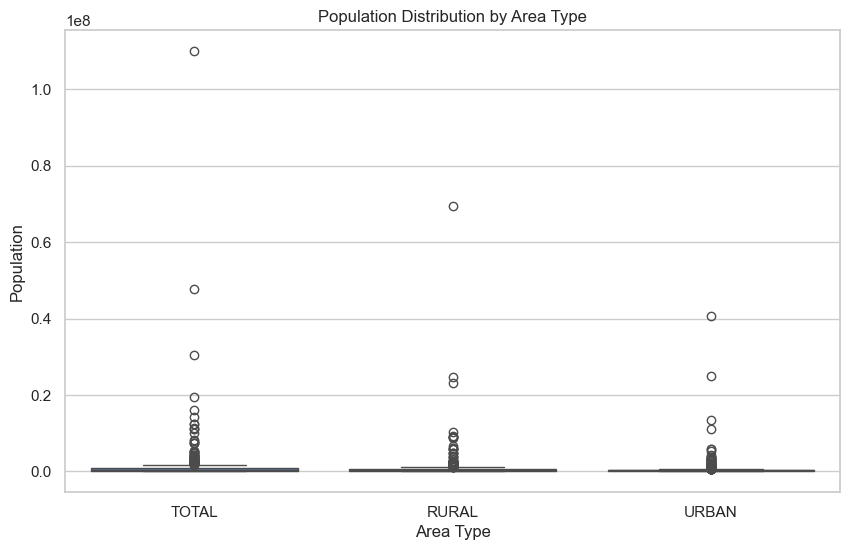

In [37]:
sns.boxplot(
    data=df,
    x="area_type",
    y="total_pop"
)

plt.title("Population Distribution by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Population")

plt.show()

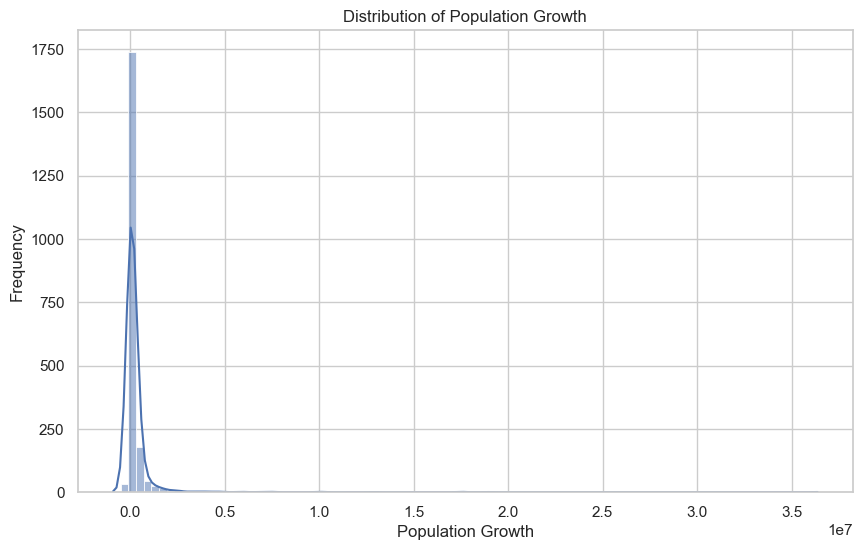

In [39]:
sns.histplot(
    df["population_growth"],
    kde=True
)

plt.title("Distribution of Population Growth")
plt.xlabel("Population Growth")
plt.ylabel("Frequency")

plt.show()

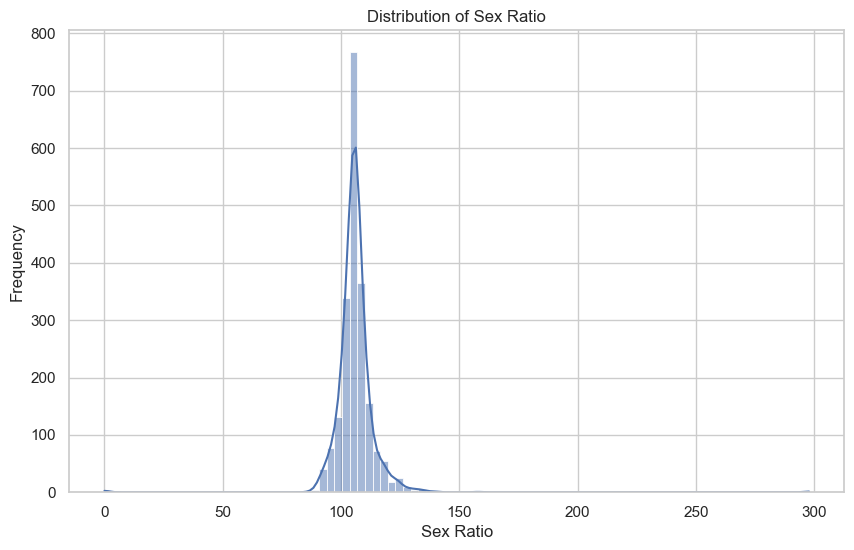

In [40]:
sns.histplot(
    df["sex_ratio"],
    kde=True
)

plt.title("Distribution of Sex Ratio")
plt.xlabel("Sex Ratio")
plt.ylabel("Frequency")

plt.show()

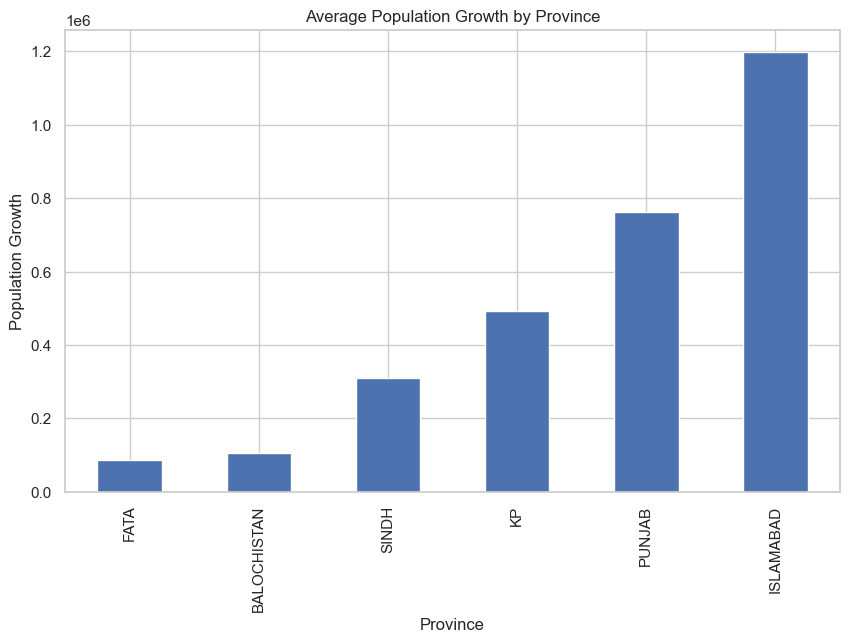

In [43]:
growth = (
    df_total.groupby("adm_lvl_1")["population_growth"]
    .mean()
)

growth.sort_values().plot(kind="bar")

plt.title("Average Population Growth by Province")
plt.xlabel("Province")
plt.ylabel("Population Growth")

plt.show()

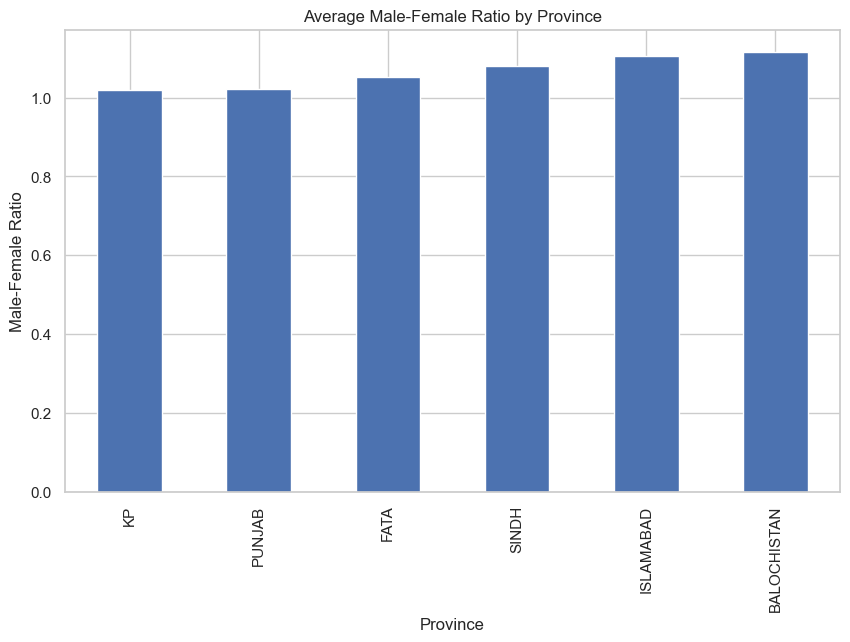

In [23]:
ratio = (
    df_total.groupby("adm_lvl_1")["male_female_ratio"]
    .mean()
)

ratio.sort_values().plot(kind="bar")

plt.title("Average Male-Female Ratio by Province")
plt.xlabel("Province")
plt.ylabel("Male-Female Ratio")

plt.show()

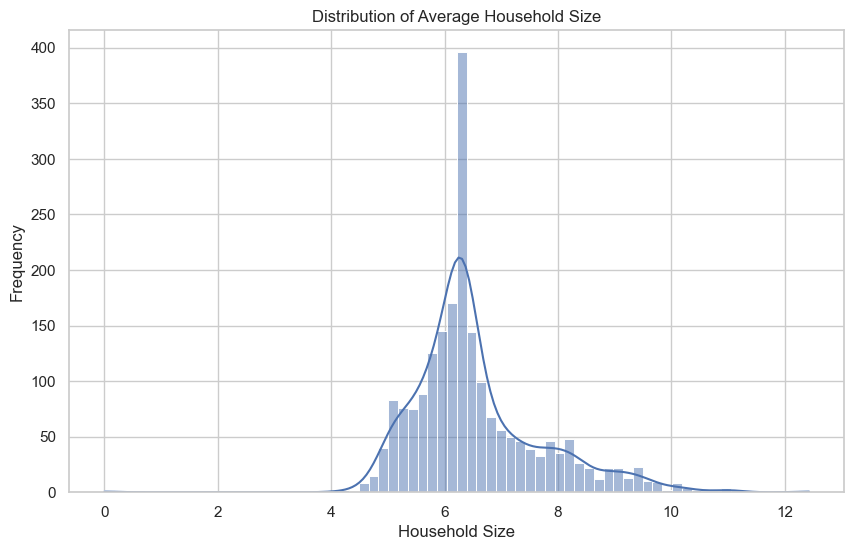

In [44]:
sns.histplot(
    df["avg_hh_size"],
    kde=True
)

plt.title("Distribution of Average Household Size")
plt.xlabel("Household Size")
plt.ylabel("Frequency")

plt.show()

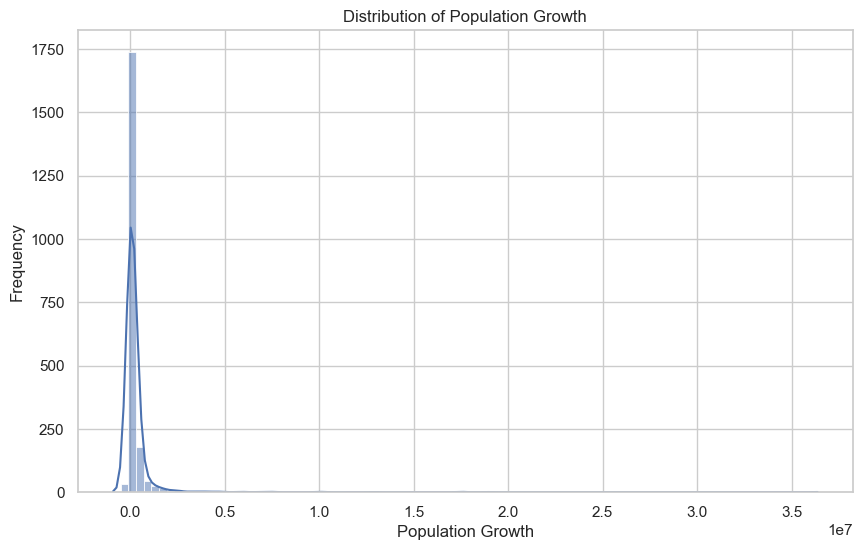

In [45]:
sns.histplot(df["population_growth"], kde=True)

plt.title("Distribution of Population Growth")
plt.xlabel("Population Growth")
plt.ylabel("Frequency")

plt.show()